In [5]:
from pyprojroot import here
import sys
sys.path.insert(0, str(here()))

In [ ]:
from src.download_utils import load_download_bounds
from src.dem import save_reprojected_dem, plot_dem

In [ ]:
region, bounds = load_download_bounds()

In [ ]:
from dem_stitcher import stitch_dem

In [8]:
print(f"Downloading regional GLO-90 DEM for projection {region.epsg}...")
tile_cache_dir = here() / "data" / "digital_elevation_model" / "download" / "glo90_cache"
tile_cache_dir.mkdir(parents=True, exist_ok=True)

elevation_data, profile = stitch_dem(
    bounds,
    dem_name='glo_90',
    dst_ellipsoidal_height=False,
    n_threads_downloading=8,
    n_threads_reproj=2,
    dst_tile_dir=tile_cache_dir,
    overwrite_existing_tiles=False,
)

/home/admin/.miniforge3/envs/skyline_env/lib/python3.10/site-packages/dem_stitcher/stitcher.py:153: UserWarning: The directory/home/admin/SkylineGeolocation/data/digital_elevation_model/download/glo90_cache exists; We are writing new files to this directory
  warn(f'The directory{tile_dir} exists; We are writing new files to this directory', category=UserWarning)
Opening glo_90 Datasets: 100%|██████████| 120/120 [00:00<00:00, 6606.50it/s]
/home/admin/.miniforge3/envs/skyline_env/lib/python3.10/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [81.99958333333333, 23.000416666666666, 82.99958333333333, 24.000416666666666]. Shrinking bounds in raster crs to (81.99958333333333, 23.274753226229752, 82.99958333333333, 24.000416666666666).
  warn(
Reading tile imagery: 100%|██████████| 120/120 [00:00<00:00, 159.31it/s]


In [11]:
dem_file = here() / "data" / "digital_elevation_model" / "dem_90m.tif"
save_reprojected_dem(elevation_data, profile, region, dem_file, resolution=90.0)

✓ Saved reprojected UTM DEM to: /home/admin/SkylineGeolocation/data/digital_elevation_model/dem_90m.tif


DEM Statistics (EPSG:32645):
 -> Minimum Elevation: -20.8 meters
 -> Maximum Elevation: 8715.2 meters
 -> Missing Data (NaN): 0.00%



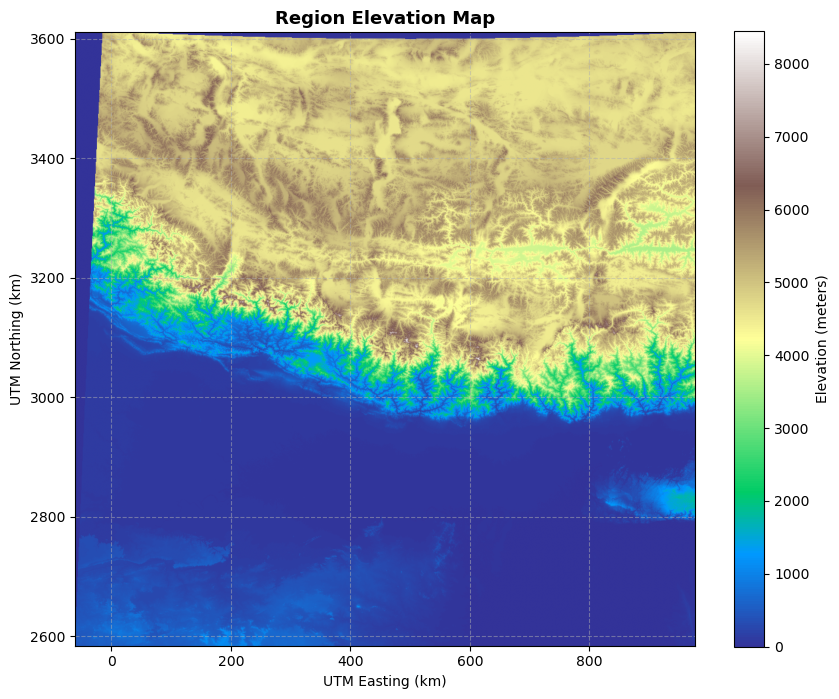

In [13]:
plot_dem(region, dem_file)